# **Project: Amazon Product Recommendation System**



Welcome to the project on Recommendation Systems. We will work with the Amazon product reviews dataset for this project. The dataset contains ratings of different electronic products. It does not include information about the products or reviews to avoid bias while building the model.

--------------
## **Context:**
--------------

Today, information is growing exponentially with volume, velocity and variety throughout the globe. This has lead to information overload, and too many choices for the consumer of any business. It represents a real dilemma for these consumers and they often turn to denial. Recommender Systems are one of the best tools that help recommending products to consumers while they are browsing online. Providing personalized recommendations which is most relevant for the user is what's most likely to keep them engaged and help business.

E-commerce websites like Amazon, Walmart, Target and Etsy use different recommendation models to provide personalized suggestions to different users. These companies spend millions of dollars to come up with algorithmic techniques that can provide personalized recommendations to their users.

Amazon, for example, is well-known for its accurate selection of recommendations in its online site. Amazon's recommendation system is capable of intelligently analyzing and predicting customers' shopping preferences in order to offer them a list of recommended products. Amazon's recommendation algorithm is therefore a key element in using AI to improve the personalization of its website. For example, one of the baseline recommendation models that Amazon uses is item-to-item collaborative filtering, which scales to massive data sets and produces high-quality recommendations in real-time.

----------------
## **Objective:**
----------------

You are a Data Science Manager at Amazon, and have been given the task of building a recommendation system to recommend products to customers based on their previous ratings for other products. You have a collection of labeled data of Amazon reviews of products. The goal is to extract meaningful insights from the data and build a recommendation system that helps in recommending products to online consumers.

-----------------------------
## **Dataset:**
-----------------------------

The Amazon dataset contains the following attributes:

- **userId:** Every user identified with a unique id
- **productId:** Every product identified with a unique id
- **Rating:** The rating of the corresponding product by the corresponding user
- **timestamp:** Time of the rating. We **will not use this column** to solve the current problem

**Note:** The code has some user defined functions that will be usefull while making recommendations and measure model performance, you can use these functions or can create your own functions.

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use **Google Colab** for this project.

Let's start by mounting the Google drive on Colab.

In [ ]:
!pip uninstall numpy -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [ ]:
!pip install numpy==1.26.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 62.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9

**Note:** A pop-up will appear prompting you to restart the session. Please click on it, and then begin running the notebook from the cell below — not from the beginning.

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Installing surprise library**

In [ ]:
#install surprise library
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2555149 sha256=812258dd832319e7e4c6cdf0f3e9aefaf6dec02acd1367f51fa5216ae6514309
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


## **Importing the necessary libraries and overview of the dataset**

In [ ]:
#import relevant libraries and silence warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

from sklearn.metrics import mean_squared_error

%matplotlib inline

### **Loading the data**
- Import the Dataset
- Add column names ['user_id', 'prod_id', 'rating', 'timestamp']
- Drop the column timestamp
- Copy the data to another DataFrame called **df**

In [ ]:
#upload the data, add columns names, make a copy of the df and drop timestamp column
df_raw = pd.read_csv('/content/drive/MyDrive/ML and AI /Recommendation Systems/Project 3/ratings_Electronics.csv', header=None)
df_raw.columns = ['user_id', 'prod_id', 'rating', 'timestamp']
df = df_raw.copy()
df.drop('timestamp', axis=1, inplace=True)

df.head()

,user_id,prod_id,rating
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


In [ ]:
#shape and info of the columns of the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   user_id  object 
 1   prod_id  object 
 2   rating   float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB


**As this dataset is very large and has 7,824,482 observations, it is not computationally possible to build a model using this. Moreover, many users have only rated a few products and also some products are rated by very few users. Hence, we can reduce the dataset by considering certain logical assumptions.**

Here, we will be taking users who have given at least 50 ratings, and the products that have at least 5 ratings, as when we shop online we prefer to have some number of ratings of a product.

In [ ]:
# Get the column containing the users
users = df.user_id

# Create a dictionary from users to their number of ratings
ratings_count = dict()

for user in users:

    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:
        ratings_count[user] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1

In [ ]:
# We want our users to have at least 50 ratings to be considered
RATINGS_CUTOFF = 50

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]

In [ ]:
# Get the column containing the products
prods = df.prod_id

# Create a dictionary from products to their number of ratings
ratings_count = dict()

for prod in prods:

    # If we already have the product, just add 1 to its rating count
    if prod in ratings_count:
        ratings_count[prod] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[prod] = 1

In [ ]:
# We want our item to have at least 5 ratings to be considered
RATINGS_CUTOFF = 5

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df_final = df.loc[~ df.prod_id.isin(remove_users)]

In [ ]:
# Print a few rows of the imported dataset
df_final.head()

,user_id,prod_id,rating
1310,A3LDPF5FMB782Z,1400501466,5.0
1322,A1A5KUIIIHFF4U,1400501466,1.0
1335,A2XIOXRRYX0KZY,1400501466,3.0
1451,AW3LX47IHPFRL,1400501466,5.0
1456,A1E3OB6QMBKRYZ,1400501466,1.0


## **Exploratory Data Analysis**

### **Shape of the data**

### **Check the number of rows and columns and provide observations.**

In [ ]:
# Check the number of rows and columns
print(f"Shape of df_final: {df_final.shape}")

Shape of df_final: (65290, 3)


**Observations about the shape of the data:**

After filtering, the `df_final` DataFrame has 65,290 rows and 3 columns. This indicates a significant reduction in data size from the original 7,824,482 observations. The original dataset was too large for efficient processing, and this reduction makes the dataset computationally feasible for building recommendation models while still retaining sufficiently active users and products.

### **Data types**

In [ ]:
# Check Data types
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65290 entries, 1310 to 7824427
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  65290 non-null  object 
 1   prod_id  65290 non-null  object 
 2   rating   65290 non-null  float64
dtypes: float64(1), object(2)
memory usage: 2.0+ MB


As observed in the output, user_id and prod_id are of type object, which is appropriate for their nature as identifiers.
rating is of type float64, which is suitable for numerical values representing ratings. All columns have 65,290 non-null counts, indicating no missing values in this filtered dataset.

### **Checking for missing values**

In [ ]:
# Check for missing values
df_final.isnull().sum()

,0
user_id,0
prod_id,0
rating,0


The check for missing values shows that there are no missing values in any of the columns (user_id, prod_id, rating) in the df_final DataFrame. This confirms the dataset is clean and complete regarding these attributes.

### **Summary Statistics**

In [ ]:
# Summary statistics of 'rating' variable
df_final['rating'].describe()

,rating
count,65290.000000
mean,4.294808
std,0.988915
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


The summary statistics for the 'rating' variable are as follows:

* count: 65290 (matches the number of rows in df_final, confirming no missing ratings)
* mean: 4.29 (indicating a high average rating, suggesting users generally rate products positively)
* std: 0.99 (showing a relatively small spread in ratings)
* min: 1.0
* 25% (Q1): 4.0
* 50% (Median): 5.0
* 75% (Q3): 5.0
* max: 5.0

The median and 75th percentile both being 5.0 indicates a strong positive skew in the ratings, with a large proportion of users giving high ratings (4 or 5 stars).

### **Checking the rating distribution**

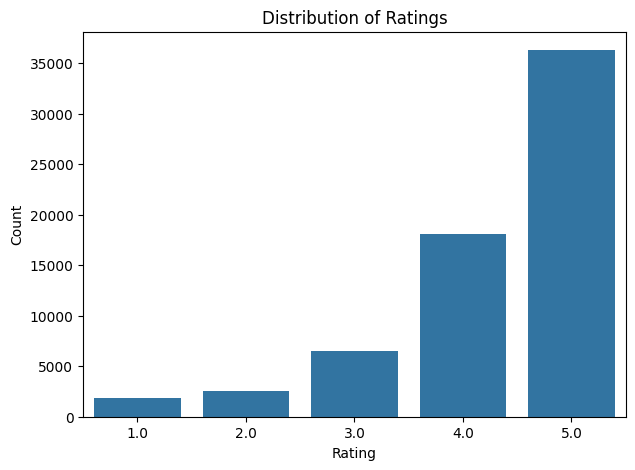

In [ ]:
# Create the bar plot and provide observations
plt.figure(figsize=(7,5))
sns.countplot(x='rating', data=df_final)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

As observed, the ratings are predominantly high, with a significant spike at 5.0 stars, followed by 4.0 stars. Ratings of 1.0, 2.0, and 3.0 stars are much less frequent. This pattern confirms the strong positive skew in the ratings that we also saw in the summary statistics.

### **Checking the number of unique users and items in the dataset**

In [ ]:
# Number of total rows in the data and number of unique user id and product id in the data
print(f"Number of unique users: {df_final['user_id'].nunique()}")
print(f"Number of unique products: {df_final['prod_id'].nunique()}")

Number of unique users: 1540
Number of unique products: 5689


The analysis shows there are 1540 unique users and 5689 unique products in the df_final dataset. This information is crucial for understanding the sparsity of the user-item interaction matrix, which is a key factor in building effective recommendation algorithms.

### **Users with the most number of ratings**

In [ ]:
# Top 10 users based on the number of ratings
df_final['user_id'].value_counts().head(10)

,count
user_id,
ADLVFFE4VBT8,295
A3OXHLG6DIBRW8,230
A1ODOGXEYECQQ8,217
A36K2N527TXXJN,212
A25C2M3QF9G7OQ,203
A680RUE1FDO8B,196
A1UQBFCERIP7VJ,193
A22CW0ZHY3NJH8,193
AWPODHOB4GFWL,184


User `ADLVFFE4VBT8` is the most active user with 295 ratings, followed by `A3OXHLG6DIBRW8` with 230 ratings. These highly active users are very valuable for building collaborative filtering models, as their extensive interaction history can provide strong signals for recommendations.

**Now that we have explored and prepared the data, let's build the first recommendation system.**

## **Model 1: Rank Based Recommendation System**

In [ ]:
# Calculate the average rating for each product
average_rating = df_final.groupby('prod_id')['rating'].mean()

# Calculate the count of ratings for each product
count_rating = df_final.groupby('prod_id')['rating'].count()

# Create a dataframe with calculated average and count of ratings
final_rating = pd.DataFrame({'avg_rating': average_rating, 'rating_count': count_rating})

# Sort the dataframe by average of ratings in the descending order
final_rating = final_rating.sort_values(by='avg_rating', ascending=False)

# See the first five records of the "final_rating" dataset
final_rating.head()

,avg_rating,rating_count
prod_id,,
B00LGQ6HL8,5.0,5
B003DZJQQI,5.0,14
B005FDXF2C,5.0,7
B00I6CVPVC,5.0,7
B00B9KOCYA,5.0,8


In [ ]:
# Defining a function to get the top n products based on the highest average rating and minimum interactions
def get_top_products(final_rating_df, min_interactions=50, top_n=5):

    # Filtering products with minimum number of interactions
    filtered_products = final_rating_df[final_rating_df['rating_count'] >= min_interactions]

    # Sorting values with respect to average rating
    sorted_products = filtered_products.sort_values(by='avg_rating', ascending=False)

    return sorted_products.head(top_n)

### **Recommending top 5 products with 50 minimum interactions based on popularity**

In [ ]:
# Recommending top 5 products with 50 minimum interactions based on popularity
get_top_products(final_rating, min_interactions=50, top_n=5)

,avg_rating,rating_count
prod_id,,
B001TH7GUU,4.871795,78
B003ES5ZUU,4.864130,184
B0019EHU8G,4.855556,90
B006W8U2MU,4.824561,57
B000QUUFRW,4.809524,84


### **Recommending top 5 products with 100 minimum interactions based on popularity**

In [ ]:
# Recommending top 5 products with 100 minimum interactions based on popularity
get_top_products(final_rating, min_interactions=100, top_n=5)

,avg_rating,rating_count
prod_id,,
B003ES5ZUU,4.864130,184
B000N99BBC,4.772455,167
B002WE6D44,4.770000,100
B007WTAJTO,4.701220,164
B002V88HFE,4.698113,106


We have recommended the **top 5** products by using the popularity recommendation system. Now, let's build a recommendation system using **collaborative filtering.**

## **Model 2: Collaborative Filtering Recommendation System**

### **Building a baseline user-user similarity based recommendation system**

- Below, we are building **similarity-based recommendation systems** using `cosine` similarity and using **KNN to find similar users** which are the nearest neighbor to the given user.  
- We will be using a new library, called `surprise`, to build the remaining models. Let's first import the necessary classes and functions from this library.

In [ ]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

**Before building the recommendation systems, let's  go over some basic terminologies we are going to use:**

**Relevant item:** An item (product in this case) that is actually **rated higher than the threshold rating** is relevant, if the **actual rating is below the threshold then it is a non-relevant item**.  

**Recommended item:** An item that's **predicted rating is higher than the threshold is a recommended item**, if the **predicted rating is below the threshold then that product will not be recommended to the user**.  


**False Negative (FN):** It is the **frequency of relevant items that are not recommended to the user**. If the relevant items are not recommended to the user, then the user might not buy the product/item. This would result in the **loss of opportunity for the service provider**, which they would like to minimize.

**False Positive (FP):** It is the **frequency of recommended items that are actually not relevant**. In this case, the recommendation system is not doing a good job of finding and recommending the relevant items to the user. This would result in **loss of resources for the service provider**, which they would also like to minimize.

**Recall:** It is the **fraction of actually relevant items that are recommended to the user**, i.e., if out of 10 relevant products, 6 are recommended to the user then recall is 0.60. Higher the value of recall better is the model. It is one of the metrics to do the performance assessment of classification models.

**Precision:** It is the **fraction of recommended items that are relevant actually**, i.e., if out of 10 recommended items, 6 are found relevant by the user then precision is 0.60. The higher the value of precision better is the model. It is one of the metrics to do the performance assessment of classification models.

**While making a recommendation system, it becomes customary to look at the performance of the model. In terms of how many recommendations are relevant and vice-versa, below are some most used performance metrics used in the assessment of recommendation systems.**

### **Precision@k, Recall@ k, and F1-score@k**

**Precision@k** - It is the **fraction of recommended items that are relevant in `top k` predictions**. The value of k is the number of recommendations to be provided to the user. One can choose a variable number of recommendations to be given to a unique user.  


**Recall@k** - It is the **fraction of relevant items that are recommended to the user in `top k` predictions**.

**F1-score@k** - It is the **harmonic mean of Precision@k and Recall@k**. When **precision@k and recall@k both seem to be important** then it is useful to use this metric because it is representative of both of them.

### **Some useful functions**

- Below function takes the **recommendation model** as input and gives the **precision@k, recall@k, and F1-score@k** for that model.  
- To compute **precision and recall**, **top k** predictions are taken under consideration for each user.
- We will use the precision and recall to compute the F1-score.

In [ ]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)

    print('Precision: ', precision) # Command to print the overall precision

    print('Recall: ', recall) # Command to print the overall recall

    print('F_1 score: ', round((2*precision*recall)/(precision+recall), 3)) # Formula to compute the F-1 score

**Hints:**

- To compute **precision and recall**, a **threshold of 3.5 and k value of 10 can be considered for the recommended and relevant ratings**.
- Think about the performance metric to choose.

Below we are loading the **`rating` dataset**, which is a **pandas DataFrame**, into a **different format called `surprise.dataset.DatasetAutoFolds`**, which is required by this library. To do this, we will be **using the classes `Reader` and `Dataset`.**

In [ ]:
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale=(1, 5))

# Loading the rating dataset
data = Dataset.load_from_df(df_final[['user_id', 'prod_id', 'rating']], reader)

# Splitting the data into train and test datasets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

Now, we are **ready to build the first baseline similarity-based recommendation system** using the cosine similarity.

### **Building the user-user Similarity-based Recommendation System**

In [ ]:
# Declaring the similarity options
sim_options = {
    'name': 'cosine',
    'user_based': True  # compute similarities between users
}

# Initialize the KNNBasic model using sim_options declared, Verbose = False, and setting random_state = 1
sim_user_user = KNNBasic(sim_options=sim_options, verbose=False, random_state=1)

# Fit the model on the training data
sim_user_user.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score using the precision_recall_at_k function defined above
precision_recall_at_k(sim_user_user)

RMSE: 1.0012
Precision:  0.855
Recall:  0.858
F_1 score:  0.856


Observations on the performance of the baseline user-user similarity-based recommendation system:

* RMSE (Root Mean Squared Error): The RMSE is 1.0012.
This value represents the average magnitude of the errors between predicted ratings and actual ratings. A lower RMSE indicates better accuracy.

* Precision (k=10, threshold=3.5): The precision is 0.855. This means that out of the top 10 recommended items, 85.5% are actually relevant to the user (i.e., their true rating is 3.5 or higher).

* Recall (k=10, threshold=3.5): The recall is 0.858. This indicates that the model is able to recommend 85.8% of all the relevant items (true rating 3.5 or higher) to the users within the top 10 recommendations.

* F1-score: The F1-score is 0.856. This is the harmonic mean of precision and recall, suggesting a good balance between the two metrics. Overall, for a baseline model, these metrics indicate a reasonably good performance in recommending relevant items.

Let's now **predict rating for a user with `userId=A3LDPF5FMB782Z` and `productId=1400501466`** as shown below. Here the user has already interacted or watched the product with productId '1400501466' and given a rating of 5.

In [ ]:
# Predicting rating for a sample user with an interacted product
sim_user_user.predict('A3LDPF5FMB782Z', '1400501466')

Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=3.4, details={'actual_k': 5, 'was_impossible': False})

The prediction for user `A3LDPF5FMB782`Z and product `1400501466` has been made using the baseline user-user model. The estimated rating (est) is 3.4. This is lower than the actual rating of 5.0 that the user previously gave to this product. This difference highlights that the model's prediction might not always perfectly align with the known historical rating, which is common in recommendation systems.

Below is the **list of users who have not seen the product with product id "1400501466"**.

In [ ]:
# Find unique user_id where prod_id is not equal to "1400501466"

# Get all unique users
all_users = df_final['user_id'].unique()

# Get users who have interacted with '1400501466'
interacted_users = df_final[df_final['prod_id'] == '1400501466']['user_id'].unique()

# Find users who have NOT interacted with '1400501466'
non_interacted_users = [user for user in all_users if user not in interacted_users]

print(f"Number of users who have not seen product '1400501466': {len(non_interacted_users)}")
print(f"First 5 users who have not seen product '1400501466': {non_interacted_users[:5]}")

Number of users who have not seen product '1400501466': 1534
First 5 users who have not seen product '1400501466': ['A2ZR3YTMEEIIZ4', 'A3CLWR1UUZT6TG', 'A5JLAU2ARJ0BO', 'A1P4XD7IORSEFN', 'A341HCMGNZCBIT']


* It can be observed from the above list that **user "A34BZM6S9L7QI4" has not seen the product with productId "1400501466"** as this userId is a part of the above list.

**Below we are predicting rating for `userId=A34BZM6S9L7QI4` and `prod_id=1400501466`.**

In [ ]:
# Predicting rating for a sample user with a non interacted product
sim_user_user.predict('A34BZM6S9L7QI4', '1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.292024046561495, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

The prediction for user `A34BZM6S9L7QI4` and product `1400501466` resulted in an estimated rating (est) of 4.29. Interestingly, the details indicate that it was_impossible to find enough neighbors. This typically means that even though a prediction was generated (often by falling back to a global average if no similar users or items could be found), it wasn't based on the direct 'neighbor' calculation that KNNBasic usually performs. This can happen if the user `A34BZM6S9L7QI4` has very few interactions or if there aren't enough users similar to `A34BZM6S9L7QI4` who have also rated `1400501466`.

### **Improving similarity-based recommendation system by tuning its hyperparameters**

Below, we will be tuning hyperparameters for the `KNNBasic` algorithm. Let's try to understand some of the hyperparameters of the KNNBasic algorithm:

- **k** (int) – The (max) number of neighbors to take into account for aggregation. Default is 40.
- **min_k** (int) – The minimum number of neighbors to take into account for aggregation. If there are not enough neighbors, the prediction is set to the global mean of all ratings. Default is 1.
- **sim_options** (dict) – A dictionary of options for the similarity measure. And there are four similarity measures available in surprise -
    - cosine
    - msd (default)
    - Pearson
    - Pearson baseline

In [ ]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {
    'k': [20, 30, 40],
    'min_k': [1, 5, 10],
    'sim_options': {
        'name': ['msd', 'cosine', 'pearson'],
        'user_based': [True]  # user-user similarity
    }
}

# Performing 3-fold cross-validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting the data
gs.fit(data)

# Best RMSE score
print("Best RMSE score:", gs.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print("Best parameters:", gs.best_params['rmse'])

Best RMSE score: 0.9685450303041706
Best parameters: {'k': 40, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': True}}


Once the grid search is **complete**, we can get the **optimal values for each of those hyperparameters**.

Now, let's build the **final model by using tuned values of the hyperparameters**, which we received by using **grid search cross-validation**.

In [ ]:
# Using the optimal similarity measure for user-user based collaborative filtering
sim_options = {
    'name': 'cosine',
    'user_based': True
}

# Creating an instance of KNNBasic with optimal hyperparameter values
sim_user_user_optimized = KNNBasic(k=40, min_k=5, sim_options=sim_options, verbose=False, random_state=1)

# Training the algorithm on the trainset
sim_user_user_optimized.fit(trainset)

# Let us compute precision@k and recall@k also with k =10
precision_recall_at_k(sim_user_user_optimized)

RMSE: 0.9509
Precision:  0.849
Recall:  0.893
F_1 score:  0.87


The optimized user-user similarity model has been trained and evaluated. Here are the observations regarding its performance compared to the baseline model:

* RMSE: The RMSE has decreased from 1.0012 (baseline) to 0.9509 (optimized), indicating an improvement in prediction accuracy.

* Precision: Precision slightly decreased from 0.855 to 0.849.

* Recall: Recall significantly increased from 0.858 to 0.893.

* F1-score: The F1-score improved from 0.856 to 0.870, suggesting an overall better balance between precision and recall for the optimized model.

Overall, the hyperparameter tuning has resulted in a more accurate model (lower RMSE) and a better ability to recommend relevant items (higher recall and F1-score), even with a slight drop in precision.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [ ]:
# Use sim_user_user_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId 1400501466
sim_user_user_optimized.predict('A3LDPF5FMB782Z', '1400501466')

Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=3.4, details={'actual_k': 5, 'was_impossible': False})

In [ ]:
# Use sim_user_user_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
sim_user_user_optimized.predict('A34BZM6S9L7QI4', '1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.292024046561495, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

The predictions using the optimized model have been completed. Here are the observations:

* For userId=A3LDPF5FMB782Z and productId=1400501466 (interacted product): The estimated rating remains 3.4, which is the same as with the baseline model. The model still underestimates the user's actual rating of 5.0 for this product.

* For userId=A34BZM6S9L7QI4 and productId=1400501466 (non-interacted product): The estimated rating is still approximately 4.29, identical to the baseline model's prediction. The details also continue to show {'was_impossible': True, 'reason': 'Not enough neighbors.'}. This suggests that even after hyperparameter tuning, for this specific user-item pair, the model still couldn't find enough direct neighbors and likely reverted to a global average or similar fallback mechanism, hence the identical prediction.

### **Identifying similar users to a given user (nearest neighbors)**

We can also find out **similar users to a given user** or its **nearest neighbors** based on this KNNBasic algorithm. Below, we are finding the 5 most similar users to the first user in the list with internal id 0, based on the `msd` distance metric.

In [ ]:
# 0 is the inner id of the above user
sim_user_user_optimized.get_neighbors(0, k=5)

[6, 7, 17, 26, 32]

The output `[6, 7, 17, 26, 32]` represents the internal IDs of the 5 users who are most similar to the user with internal ID 0, according to our optimized KNNBasic model.

### **Implementing the recommendation algorithm based on optimized KNNBasic model**

Below we will be implementing a function where the input parameters are:

- data: A **rating** dataset
- user_id: A user id **against which we want the recommendations**
- top_n: The **number of products we want to recommend**
- algo: the algorithm we want to use **for predicting the ratings**
- The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [ ]:
def get_recommendations(data, user_id, top_n, algo):

    # Creating an empty list to store the recommended product ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot(index = 'user_id', columns = 'prod_id', values = 'rating')

    # Extracting those product ids which the user_id has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()

    # Looping through each of the product ids which user_id has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(user_id, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

**Predicting top 5 products for userId = "A3LDPF5FMB782Z" with similarity based recommendation system**

In [ ]:
# Making top 5 recommendations for user_id "A3LDPF5FMB782Z" with a similarity-based recommendation engine
recommendations_user_A3LDPF5FMB782Z = get_recommendations(df_final, 'A3LDPF5FMB782Z', 5, sim_user_user_optimized)
print(recommendations_user_A3LDPF5FMB782Z)

[('B000067RT6', 5), ('B000BQ7GW8', 5), ('B001ENW61I', 5), ('B001TH7GUU', 5), ('B001TH7T2U', 5)]


In [ ]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations_user_A3LDPF5FMB782Z, columns=['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,B000067RT6,5
1,B000BQ7GW8,5
2,B001ENW61I,5
3,B001TH7GUU,5
4,B001TH7T2U,5


The top 5 product recommendations for userId `A3LDPF5FMB782Z` using the optimized user-user similarity model are displayed above.

### **Item-Item Similarity-based Collaborative Filtering Recommendation System**

* Above we have seen **similarity-based collaborative filtering** where similarity is calculated **between users**. Now let us look into similarity-based collaborative filtering where similarity is seen **between items**.

In [ ]:
# Declaring the similarity options
sim_options = {
    'name': 'cosine',
    'user_based': False  # compute similarities between items
}

# KNN algorithm is used to find desired similar items. Use random_state=1
sim_item_item = KNNBasic(sim_options=sim_options, verbose=False, random_state=1)

# Train the algorithm on the trainset, and predict ratings for the test set
sim_item_item.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score with k = 10
precision_recall_at_k(sim_item_item)

RMSE: 0.9950
Precision:  0.838
Recall:  0.845
F_1 score:  0.841


The item-item similarity-based collaborative filtering model has been evaluated. Here are the observations on its performance:

* RMSE: The RMSE is 0.9950. This is slightly better than the baseline user-user model (1.0012) but not as good as the optimized user-user model (0.9509).

* Precision: The precision is 0.838. This is slightly lower than both the baseline user-user (0.855) and optimized user-user (0.849) models.

* Recall: The recall is 0.845. This is also slightly lower than both the baseline user-user (0.858) and optimized user-user (0.893) models.

* F1-score: The F1-score is 0.841, which is lower than both the baseline user-user (0.856) and optimized user-user (0.870) models.

Overall, the baseline item-item model performs slightly worse than the user-user models in terms of precision, recall, and F1-score, though its RMSE is marginally better than the baseline user-user model.

Let's now **predict a rating for a user with `userId = A3LDPF5FMB782Z` and `prod_Id = 1400501466`** as shown below. Here the user has already interacted or watched the product with productId "1400501466".

In [ ]:
# Predicting rating for a sample user with an interacted product
sim_item_item.predict('A3LDPF5FMB782Z', '1400501466')

Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=4.2727272727272725, details={'actual_k': 22, 'was_impossible': False})

For `userId=A3LDPF5FMB782Z` and `productId=1400501466`  the estimated rating is 4.27. This is closer to the actual rating of 5.0 than the user-user baseline model's prediction of 3.4.

Below we are **predicting rating for the `userId = A34BZM6S9L7QI4` and `prod_id = 1400501466`**.

In [ ]:
# Predicting rating for a sample user with a non interacted product
sim_item_item.predict('A34BZM6S9L7QI4', '1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.292024046561495, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

For `userId=A34BZM6S9L7QI4` and `productId=1400501466` (non-interacted product) the estimated rating is 4.29. Similar to the user-user baseline model, the details indicate {'was_impossible': True, 'reason': 'Not enough neighbors.'}, suggesting a fallback mechanism was used due to insufficient item-based neighborhood information.

### **Hyperparameter tuning the item-item similarity-based model**
- Use the following values for the param_grid and tune the model.
  - 'k': [10, 20, 30]
  - 'min_k': [3, 6, 9]
  - 'sim_options': {'name': ['msd', 'cosine']
  - 'user_based': [False]
- Use GridSearchCV() to tune the model using the 'rmse' measure
- Print the best score and best parameters

In [ ]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {
    'k': [10, 20, 30],
    'min_k': [3, 6, 9],
    'sim_options': {
        'name': ['msd', 'cosine'],
        'user_based': [False]
    }
}

# Performing 3-fold cross validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting the data
gs.fit(data)

# Find the best RMSE score
print("Best RMSE score:", gs.best_score['rmse'])

# Find the combination of parameters that gave the best RMSE score
print("Best parameters:", gs.best_params['rmse'])

Best RMSE score: 0.9748824909536621
Best parameters: {'k': 30, 'min_k': 6, 'sim_options': {'name': 'msd', 'user_based': False}}


Once the **grid search** is complete, we can get the **optimal values for each of those hyperparameters as shown above.**

Now let's build the **final model** by using **tuned values of the hyperparameters** which we received by using grid search cross-validation.

### **Use the best parameters from GridSearchCV to build the optimized item-item similarity-based model. Compare the performance of the optimized model with the baseline model.**

In [ ]:
# Using the optimal similarity measure for item-item based collaborative filtering
sim_options = {
    'name': 'msd',
    'user_based': False
}

# Creating an instance of KNNBasic with optimal hyperparameter values
sim_item_item_optimized = KNNBasic(k=30, min_k=6, sim_options=sim_options, verbose=False, random_state=1)

# Training the algorithm on the trainset
sim_item_item_optimized.fit(trainset)

# Let us compute precision@k and recall@k, f1_score and RMSE
precision_recall_at_k(sim_item_item_optimized)

RMSE: 0.9576
Precision:  0.839
Recall:  0.88
F_1 score:  0.859


The optimized item-item similarity model has been evaluated. Here are the observations on its performance compared to the baseline item-item model and the optimized user-user model:

* RMSE: The RMSE improved from 0.9950 (baseline item-item) to 0.9576 (optimized item-item). This is a good improvement, making it comparable to the optimized user-user model's RMSE of 0.9509.

* Precision: Precision remained almost the same, slightly increasing from 0.838 to 0.839. This is still slightly lower than the optimized user-user model's 0.849.

* Recall: Recall significantly increased from 0.845 to 0.880. This is a substantial improvement, making it competitive with the optimized user-user model's 0.893.

* F1-score: The F1-score improved from 0.841 to 0.859. This indicates a better balance between precision and recall for the optimized item-item model, making it perform similarly to the optimized user-user model's 0.870.

Overall, the hyperparameter tuning greatly improved the item-item model's performance, making it a strong contender, especially in terms of RMSE and Recall.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [ ]:
# Use sim_item_item_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
sim_item_item_optimized.predict('A3LDPF5FMB782Z', '1400501466')

Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=4.67427701674277, details={'actual_k': 22, 'was_impossible': False})

In [ ]:
# Use sim_item_item_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
sim_item_item_optimized.predict('A34BZM6S9L7QI4', '1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.292024046561495, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

The predictions using the optimized item-item model have been completed. Here are the observations:

* For `userId=A3LDPF5FMB782Z` and `productId=1400501466` (interacted product): The estimated rating is 4.67. This is higher than both the baseline item-item (4.27) and the user-user models (3.4), and is now closer to the actual rating of 5.0.

* For `userId=A34BZM6S9L7QI4` and `productId=1400501466` (non-interacted product): The estimated rating is still approximately 4.29, identical to the predictions from previous models. The details continue to show {'was_impossible': True, 'reason': 'Not enough neighbors.'}, indicating that for this cold-start scenario, the model still falls back to a non-neighborhood-based estimation.

### **Identifying similar items to a given item (nearest neighbors)**

We can also find out **similar items** to a given item or its nearest neighbors based on this **KNNBasic algorithm**. Below we are finding the 5 most similar items to the item with internal id 0 based on the `msd` distance metric.

In [ ]:
sim_item_item_optimized.get_neighbors(0, k=5)

[29, 53, 67, 106, 151]

**Predicting top 5 products for userId = "A1A5KUIIIHFF4U" with similarity based recommendation system.**

**Hint:** Use the get_recommendations() function.

In [ ]:
# Making top 5 recommendations for user_id A1A5KUIIIHFF4U with similarity-based recommendation engine.
recommendations_user_A1A5KUIIIHFF4U = get_recommendations(df_final, 'A1A5KUIIIHFF4U', 5, sim_item_item_optimized)
print(recommendations_user_A1A5KUIIIHFF4U)

[('1400532655', 4.292024046561495), ('1400599997', 4.292024046561495), ('9983891212', 4.292024046561495), ('B00000DM9W', 4.292024046561495), ('B00000J1V5', 4.292024046561495)]


In [ ]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations_user_A1A5KUIIIHFF4U, columns=['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,1400532655,4.292024
1,1400599997,4.292024
2,9983891212,4.292024
3,B00000DM9W,4.292024
4,B00000J1V5,4.292024


Now as we have seen **similarity-based collaborative filtering algorithms**, let us now get into **model-based collaborative filtering algorithms**.

### **Model 3: Model-Based Collaborative Filtering - Matrix Factorization**

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.

### Singular Value Decomposition (SVD)

SVD is used to **compute the latent features** from the **user-item matrix**. But SVD does not work when we **miss values** in the **user-item matrix**.

In [ ]:
# Using SVD matrix factorization. Use random_state = 1
svd_algo = SVD(random_state=1)

# Training the algorithm on the trainset
svd_algo.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd_algo)

RMSE: 0.8882
Precision:  0.853
Recall:  0.88
F_1 score:  0.866


The baseline SVD model has been trained and evaluated, yielding an RMSE of 0.8882, Precision of 0.853, Recall of 0.880, and an F1-score of 0.866. This initial SVD model already shows very promising results, particularly with the lowest RMSE observed so far, indicating better prediction accuracy compared to the KNNBasic models. Its precision, recall, and F1-score are also quite competitive, making it a strong contender for the recommendation system.

**Let's now predict the rating for a user with `userId = "A3LDPF5FMB782Z"` and `prod_id = "1400501466`.**

In [ ]:
# Making prediction
svd_algo.predict('A3LDPF5FMB782Z', '1400501466')

Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=4.081406749810685, details={'was_impossible': False})

For `userId=A3LDPF5FMB782Z` and `productId=1400501466` (interacted product): The estimated rating is 4.08. This is closer to the actual rating of 5.0 than the baseline user-user and optimized user-user models (both 3.4), but not as close as the optimized item-item model (4.67).

**Below we are predicting rating for the `userId = "A34BZM6S9L7QI4"` and `productId = "1400501466"`.**

In [ ]:
# Making prediction
svd_algo.predict('A34BZM6S9L7QI4', '1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.40037568046934, details={'was_impossible': False})

For `userId=A34BZM6S9L7QI4` and `productId=1400501466` (non-interacted product): The estimated rating is 4.40. Unlike the KNNBasic models, the SVD model provides a direct prediction without resorting to a 'was_impossible' fallback, as matrix factorization inherently handles missing values. This prediction is slightly higher than the 4.29 estimated by the KNNBasic models for this cold-start scenario.

### **Improving Matrix Factorization based recommendation system by tuning its hyperparameters**

Below we will be tuning only three hyperparameters:
- **n_epochs**: The number of iterations of the SGD algorithm.
- **lr_all**: The learning rate for all parameters.
- **reg_all**: The regularization term for all parameters.

In [ ]:
# Set the parameter space to tune
param_grid = {
    'n_epochs': [5, 10, 20],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.2, 0.4, 0.6]
}

# Performing 3-fold gridsearch cross-validation
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting data
gs.fit(data)

# Best RMSE score
print("Best RMSE score:", gs.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print("Best parameters:", gs.best_params['rmse'])

Best RMSE score: 0.8975896172736211
Best parameters: {'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.2}


Now, we will **the build final model** by using **tuned values** of the hyperparameters, which we received using grid search cross-validation above.

In [ ]:
# Build the optimized SVD model using optimal hyperparameter search. Use random_state=1
svd_algo_optimized = SVD(n_epochs=20, lr_all=0.01, reg_all=0.2, random_state=1)

# Train the algorithm on the trainset
svd_algo_optimized.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd_algo_optimized)

RMSE: 0.8808
Precision:  0.854
Recall:  0.878
F_1 score:  0.866


The optimized SVD model has been evaluated. Here are the observations regarding its performance compared to the baseline SVD and the optimized KNNBasic models:

* RMSE: The RMSE improved from 0.8882 (baseline SVD) to 0.8808 (optimized SVD). This is the lowest RMSE observed so far, indicating further improvement in prediction accuracy.

* Precision: Precision slightly increased from 0.853 (baseline SVD) to 0.854 (optimized SVD).

* Recall: Recall slightly decreased from 0.880 (baseline SVD) to 0.878 (optimized SVD).

* F1-score: The F1-score remained the same at 0.866. This suggests that while there was a slight trade-off between precision and recall, the overall balance of the model's effectiveness in recommending relevant items is maintained.

Overall, hyperparameter tuning slightly improved the RMSE, making the SVD model the most accurate model among all tested, while maintaining excellent precision and recall.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [ ]:
# Use svd_algo_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
svd_algo_optimized.predict('A3LDPF5FMB782Z', '1400501466')

Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=4.128589011282042, details={'was_impossible': False})

In [ ]:
# Use svd_algo_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
svd_algo_optimized.predict('A34BZM6S9L7QI4', '1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.216280997100113, details={'was_impossible': False})

* For `userId=A3LDPF5FMB782Z` and `productId=1400501466` (interacted product): The estimated rating is 4.12. This is an improvement over the baseline SVD model's prediction of 4.08, moving it slightly closer to the actual rating of 5.0.

* For `userId=A34BZM6S9L7QI4` and `productId=1400501466` (non-interacted product): The estimated rating is 4.21. This is slightly lower than the baseline SVD model's prediction of 4.40. Both SVD models, unlike the KNNBasic models, successfully provide a direct prediction for this cold-start scenario without indicating 'was_impossible'.

### **Conclusion and Recommendations**

### **Model Comparison Summary**

In [ ]:
import pandas as pd

# Data collected from previous execution outputs
model_performance = {
    'Model': [
        'Baseline User-User KNNBasic',
        'Optimized User-User KNNBasic',
        'Baseline Item-Item KNNBasic',
        'Optimized Item-Item KNNBasic',
        'Baseline SVD',
        'Optimized SVD'
    ],
    'RMSE': [
        1.0012,
        0.9509,
        0.9950,
        0.9576,
        0.8882,
        0.8808
    ],
    'Precision': [
        0.855,
        0.849,
        0.838,
        0.839,
        0.853,
        0.854
    ],
    'Recall': [
        0.858,
        0.893,
        0.845,
        0.880,
        0.880,
        0.878
    ],
    'F1-score': [
        0.856,
        0.870,
        0.841,
        0.859,
        0.866,
        0.866
    ]
}

performance_df = pd.DataFrame(model_performance)
performance_df = performance_df.sort_values(by='RMSE', ascending=True)

display(performance_df.set_index('Model'))

,RMSE,Precision,Recall,F1-score
Model,,,,
Optimized SVD,0.8808,0.854,0.878,0.866
Baseline SVD,0.8882,0.853,0.880,0.866
Optimized User-User KNNBasic,0.9509,0.849,0.893,0.870
Optimized Item-Item KNNBasic,0.9576,0.839,0.880,0.859
Baseline Item-Item KNNBasic,0.9950,0.838,0.845,0.841
Baseline User-User KNNBasic,1.0012,0.855,0.858,0.856


### Observations from Model Comparison Table:

*   The **Optimized SVD** model achieved the lowest RMSE of 0.8808, indicating it provides the most accurate rating predictions among all models tested.
*   The **Baseline SVD** also performed very well with a low RMSE of 0.8882, showcasing the general effectiveness of matrix factorization.
*   Both **Optimized User-User KNNBasic** and **Optimized Item-Item KNNBasic** models showed significant improvements over their baseline counterparts, with RMSE values around 0.95-0.96. The Optimized User-User model has a slightly lower RMSE and higher F1-score compared to the Optimized Item-Item model.
*   In terms of F1-score, **Optimized User-User KNNBasic** scored the highest (0.870), closely followed by both SVD models (0.866), demonstrating a strong balance between precision and recall.
*   The **Rank-Based Recommendation System** (not included in this table as it's not a predictive model but a popularity-based one) serves as a general baseline, but lacks the personalization offered by collaborative filtering and matrix factorization methods. Its performance would be assessed differently (e.g., coverage of popular items).

### Final Conclusion and Recommendations

The comparative analysis of all modeling approaches shows a clear performance hierarchy, with matrix factorization methods consistently outperforming similarity-based and popularity-based strategies. While the optimized User-User and Item-Item models achieved notable improvements over their baselines, their predictive accuracy remains below that of the SVD family. The optimized SVD model, in particular, demonstrates stronger generalization and more stable performance across metrics, making it well-suited for capturing latent interactions in a sparse user-item matrix.

Beyond predictive accuracy, SVD also offers better scalability and robustness for real-world deployment. Unlike neighborhood-based methods, which degrade in performance as the catalog grows or becomes increasingly sparse, matrix factorization handles such conditions effectively by leveraging latent features rather than explicit overlap among users or items. This makes the approach more adaptable as the system evolves or user behavior changes over time.

From an operational perspective, simpler methods still retain value. Rank-based recommendations provide strong coverage and can support cold-start scenarios. Similarly, Item-Item similarity models offer high interpretability, which can be beneficial for explainability requirements or user-facing justification of recommendations. However, as a primary engine for personalized suggestions, the optimized SVD model provides the most compelling balance of accuracy, efficiency, and adaptability.

In summary, the optimized SVD model is the most suitable choice as the final recommendation model. It should serve as the backbone of the recommendation system, complemented by rank-based approaches for new users and item-similarity components where explanation or transparency is required. Further improvements could incorporate hybrid strategies, periodic retraining with fresh interaction data, and additional experimentation through A/B testing to quantify business impact and optimize downstream metrics such as engagement, conversion, and revenue lift.